## **CQF Exam 3**

Install Packages & Import Libraries

In [5]:
# Install packages
# !pip install -q xgboost wandb pyfolio-reloaded yfinance

In [9]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Project Objectives**
<p>
The objective of this project is to develop a model to predict positive market moves on SPDR Gold Shares (Ticker: GLD) using Machine Learning (ML) techniques.
</p>

<p>
GLD is one of the largest exchange-traded funds (ETF) by asset under management (AUM), designed to track the spot price of physical gold. It was selected for several reasons: the ETF has two decades of trading history with ample data availability, maintains a high daily transaction volume, and its underlying asset is sensitive to macroeconomic factors — making it a strong candidate for ML classification with rich features to explore.
</p>
<p>
A five-year horizon from 2020-01-01 to 2025-12-31 is used, covering multiple macroeconomic regimes including the COVID-19 crash, the zero-rate era, the aggressive rate-hike cycle and the subsequent policy pivot.
</p>
<p>
Short-term asset returns are typically characterized by low-signal to noise ratios, potentially filled with small near-zero returns. Overfitting is therefore key risk, and XGBoost addresses this issue by incorporating a regularized objective function which combines the training loss with explicit penalties on tree structure (γ) and leaf weights (λ), discouraging the model from memorizing the noise in training data. XGBoost also has built-in early stopping, parallel tree construction and ability to handle missing values, making it a well-suited for multi-sourced, large feature sets which will be used in this study.
</p>

## **A) Explanation of Entropy in Classification**
<p>
What does entropy reveal about the quality of the partitions in a classifiation problem?
</p>

Entropy measures the impurity or uncertainty of a partition in a classification problem. The formula is:

$$H(S) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

where:
- $C$ = number of classes
- $p_i$ = proportion of observations in class $i$ inside the partition
- $\log_2$ means log base 2
<br>
<p>
For binary classification, where classes are 0 and 1:
</p>
$$H(S) = -p \log_2(p) - (1-p) \log_2(1-p)$$
<br>
where $p$ is the proportion of class 1, and $1-p$ is the proportion of class 0.
<br>
<p>
A pure partition, where all observations belong to one class, entropy equal to zero because the partition is perfectly pure. At the other extreme is when entropy is at max where observations and its split is basically 50/50. </p><br>

| Class mix in partition | Entropy | Meaning |
|:---|:---|:---|
| 100% / 0% i.e. $-1.0\log_2(1.0) - 0\log_2(0)$ | 0 | Pure |
| 90% / 10% i.e. $-0.9\log_2(0.9) - 0.1\log_2(0.1)$ | 0.469 | Mostly pure |
| 70% / 30% i.e. $-0.7\log_2(0.7) - 0.3\log_2(0.3)$ | 0.881 | Some impurity |
| 50% / 50% i.e. $-0.5\log_2(0.5) - 0.5\log_2(0.5)$ | 1.000 | Most impure |

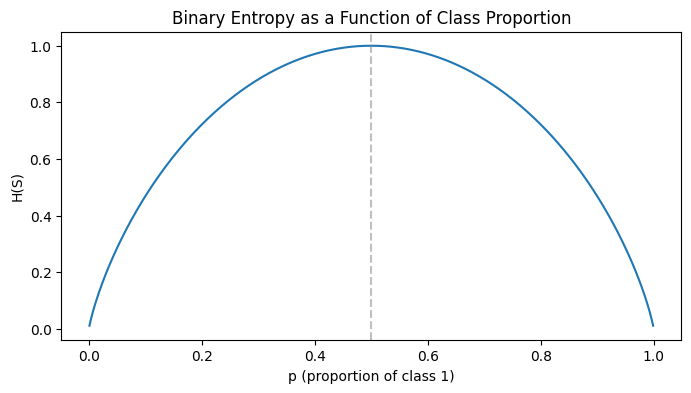

In [10]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.001, 0.999, 500)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

plt.figure(figsize=(8, 4))
plt.plot(p, H)
plt.xlabel('p (proportion of class a)')
plt.ylabel('H(S)')
plt.title('Binary Entropy as a Function of Class Proportion')
plt.axvline(x=0.5, linestyle='--', color='grey', alpha=0.5)
plt.show()

(a) High entropy means the partitions are pure - **False**
<p>
High entropy in this scenario would mean in the binary classification, classes (0, 1) are almost evenly split, meaning we are uncertain which class an observation should belong to, it is impure. </p>

(b) High entropy means the partitions are impure - **True**
<p>
As we just walked through in the above where high entropy is where classes (0, 1) is observed in different classes. Maximum entropy occurs when classes are evenly split and that signals partitions are impure. A good decision-tree split should reduce entropy in the child nodes, producing higher information gain. The information gain formula is defined as follow:
</p>

$$IG = H(\text{parent}) - \frac{|S_L|}{|S|} H(S_L) - \frac{|S_R|}{|S|} H(S_R)$$

<p>
At every tree split, the algorithm aims to select a split that maximizes IG, driving child nodes toward lower entropy (purer partitions).
</p>

<p>
Applying this to the GLD price direction prediction, each split with XGBoost will seek to separate positive-move days from negative-move days as cleanly as possible, reducing entropy at each node.
</p>
